In [1]:
import pandas as pd
import seaborn as sns
sns.set_theme()

In [59]:
df = pd.read_csv("metrics.csv")

In [60]:
df = df[df["actual_val"]>0.0]

In [61]:
from matplotlib import pyplot as plt

In [62]:
unique_cond_values = df["cond_scale"].unique()

In [63]:
cond_dfs = []
for value in unique_cond_values:
    cond_dfs.append(df[df["cond_scale"]==value])

In [64]:
unique_column_values = cond_dfs[0]["column"].unique()

In [65]:
len(cond_dfs)

4

In [66]:
from sklearn.metrics import r2_score

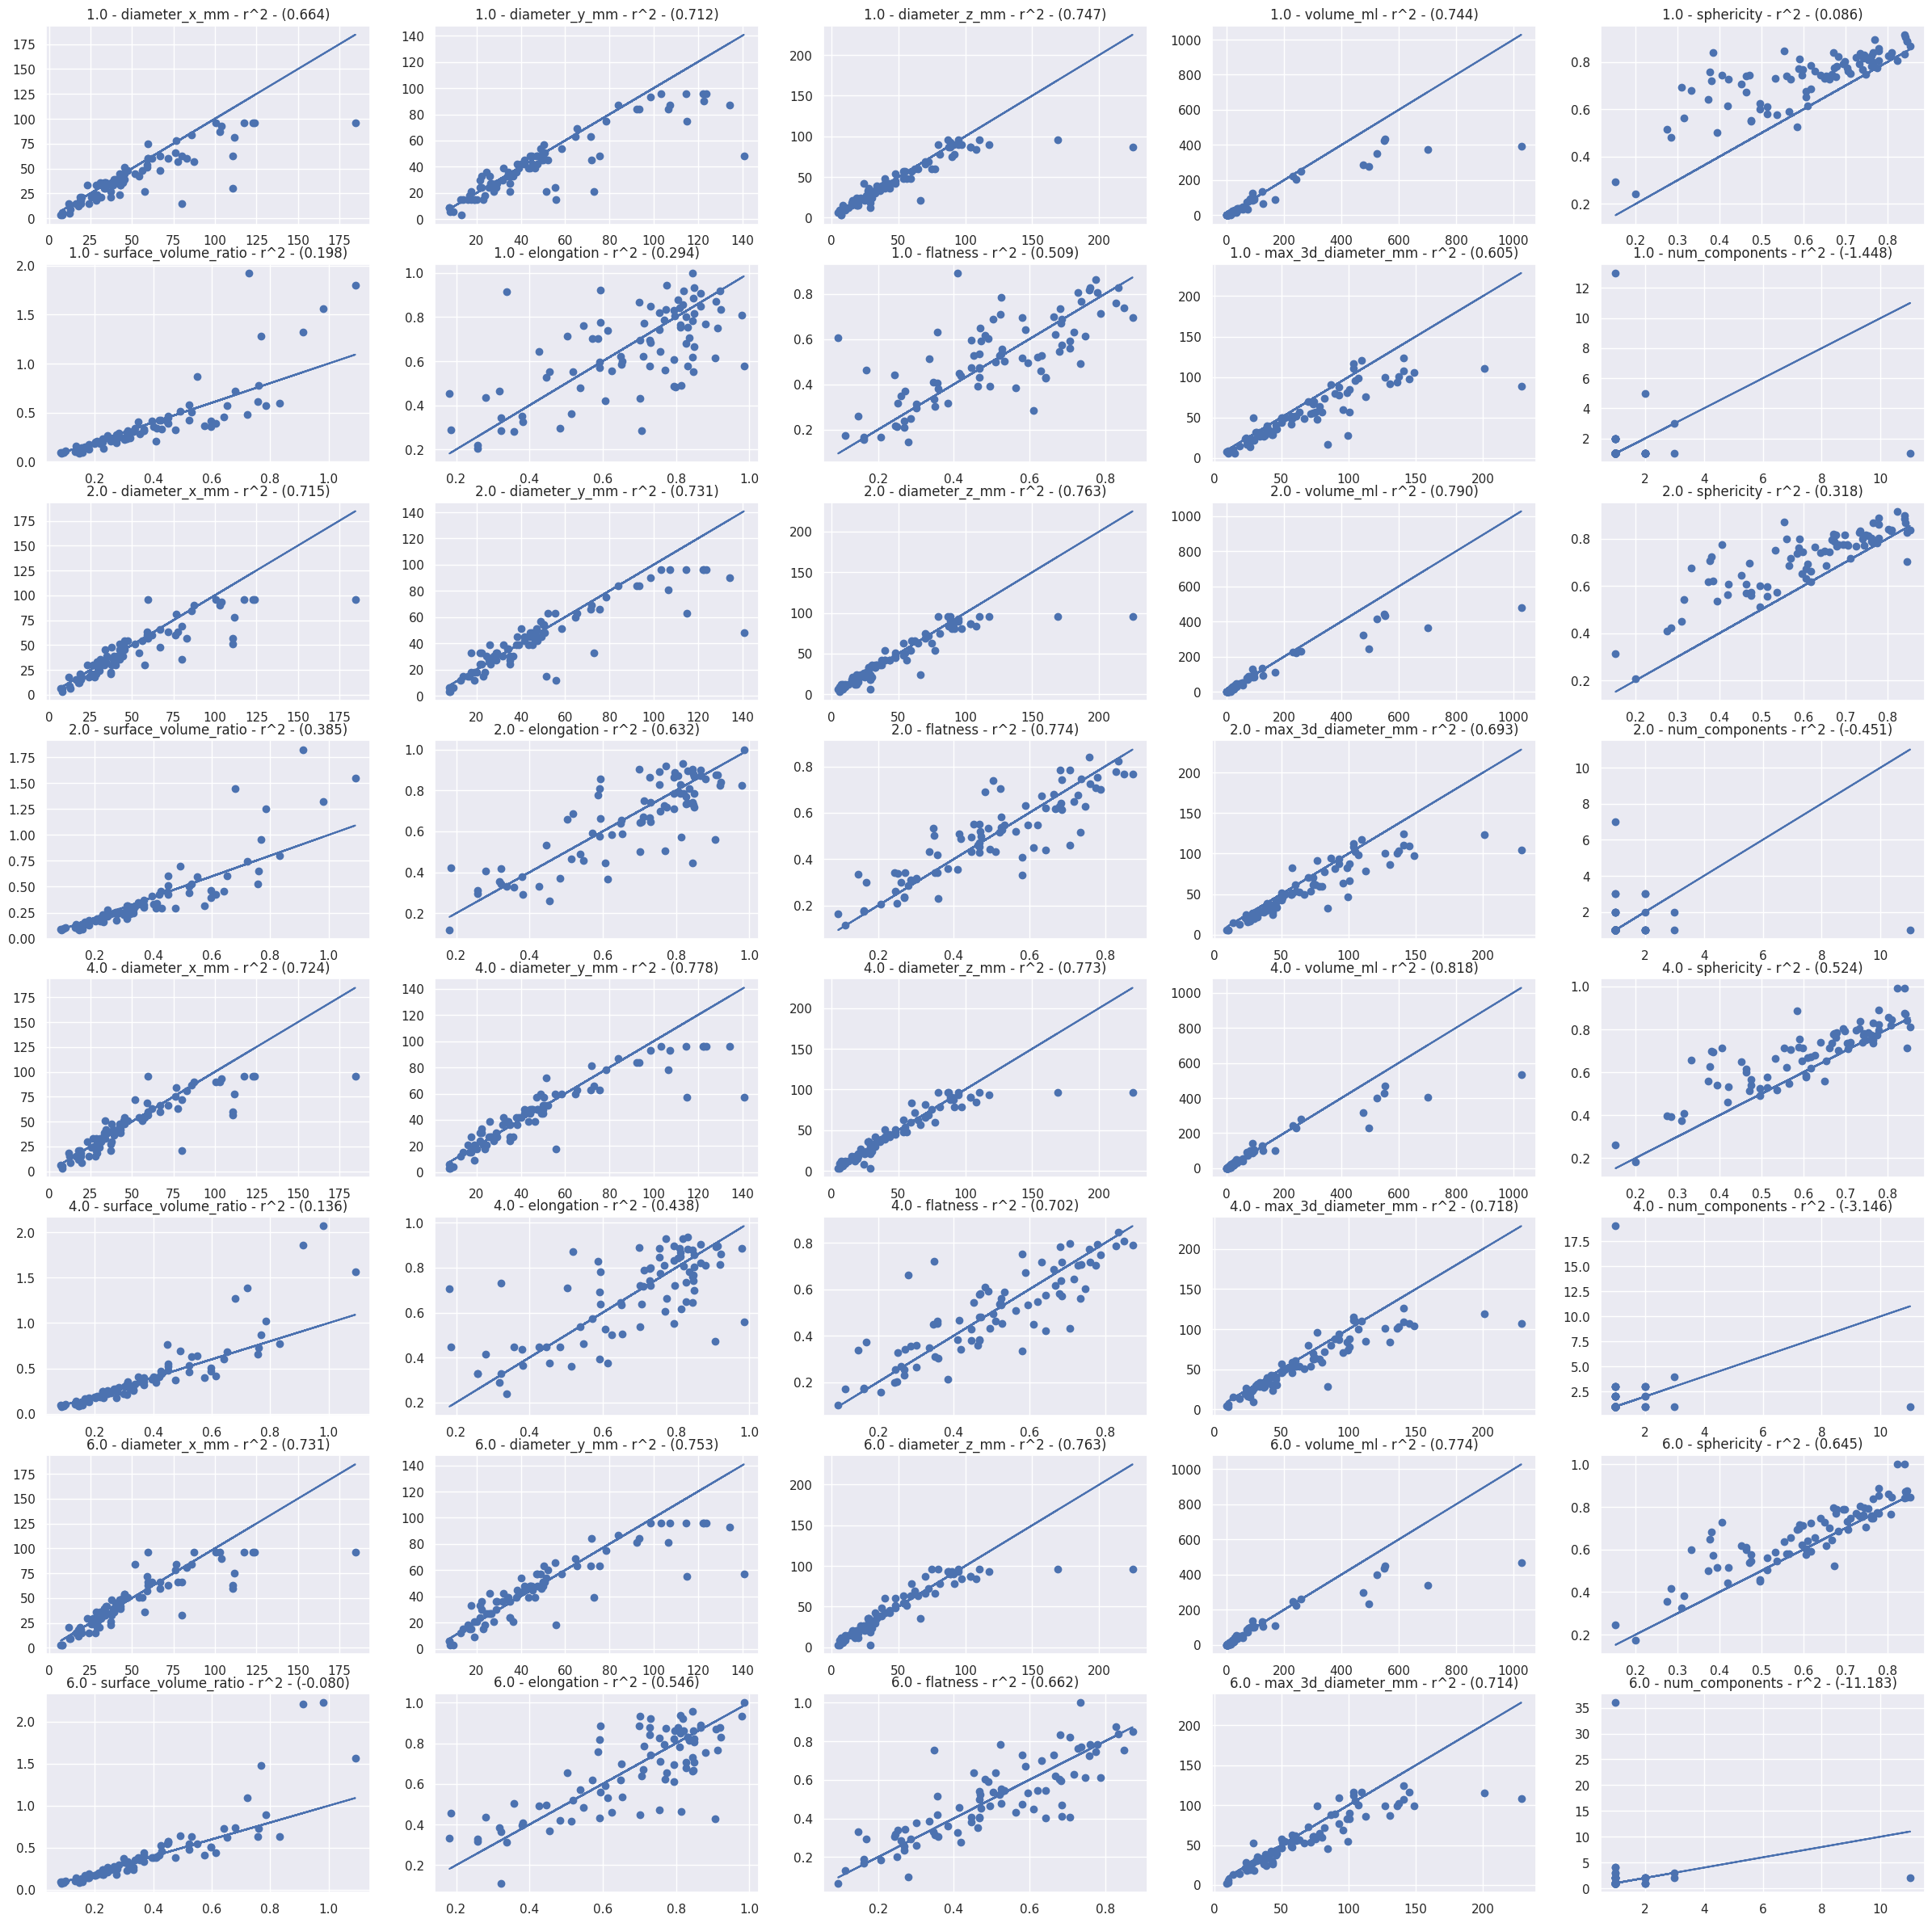

In [83]:
fig, ax = plt.subplots(8, 5, figsize=(30,30))
# Flatten the 2D array of axes into a 1D array of 40 elements
axes_flat = ax.flatten()
r2_vals = []

steps = 0
for i, cond in enumerate(cond_dfs):
    for j, col in enumerate(unique_column_values):
        # Prevent IndexError if your data exceeds 40 combinations
        if steps >= len(axes_flat):
            print("Warning: More data combinations than available subplots!")
            break
            
        col_rows = cond[cond["column"] == col]
        
        # Directly index the flattened axes
        current_ax = axes_flat[steps]
        
        current_ax.scatter(col_rows["desired_val"], col_rows["actual_val"])
        current_ax.plot(col_rows["desired_val"],col_rows["desired_val"])
        r2 = r2_score(col_rows["desired_val"], col_rows["actual_val"])
        current_ax.set_title(f"{unique_cond_values[i]} - {col} - r^2 - ({r2:.3f})")
        r2_vals.append({"r2":r2,"cond":unique_cond_values[i],"col":col})
        steps += 1

In [70]:
pd.DataFrame(r2_vals)

,r2,cond,col
0,0.663607,1.0,diameter_x_mm
1,0.712304,1.0,diameter_y_mm
2,0.747419,1.0,diameter_z_mm
3,0.744410,1.0,volume_ml
4,0.086169,1.0,sphericity
5,0.198019,1.0,surface_volume_ratio
6,0.294284,1.0,elongation
7,0.509149,1.0,flatness
8,0.604920,1.0,max_3d_diameter_mm
9,-1.447739,1.0,num_components


In [82]:
for i, cond in enumerate(cond_dfs):
    for j, col in enumerate(unique_column_values):
        col_rows = cond[cond["column"] == col]
        print(f"Cond: {unique_cond_values[i]} - Col: {col}")
        r2 = r2_score(col_rows["desired_val"], col_rows["actual_val"])
        print(f"R^2: {r2}")
        percent_error = (abs(col_rows['desired_val']-col_rows['actual_val'])/col_rows['desired_val']).mean() * 100
        print(f"Percent error: {percent_error}")

        print("=============")

Cond: 1.0 - Col: diameter_x_mm
R^2: 0.6636066419831844
Percent error: 20.271124950334
Cond: 1.0 - Col: diameter_y_mm
R^2: 0.7123039477875561
Percent error: 18.377611429713365
Cond: 1.0 - Col: diameter_z_mm
R^2: 0.747419160891206
Percent error: 17.185820513055504
Cond: 1.0 - Col: volume_ml
R^2: 0.7444103396061001
Percent error: 26.21428683562148
Cond: 1.0 - Col: sphericity
R^2: 0.08616868242486053
Percent error: 26.73505194363407
Cond: 1.0 - Col: surface_volume_ratio
R^2: 0.1980193268157725
Percent error: 19.756569712974194
Cond: 1.0 - Col: elongation
R^2: 0.294284382328844
Percent error: 21.931559634135088
Cond: 1.0 - Col: flatness
R^2: 0.5091491505064308
Percent error: 28.27936033369115
Cond: 1.0 - Col: max_3d_diameter_mm
R^2: 0.6049197412314025
Percent error: 22.045704229103517
Cond: 1.0 - Col: num_components
R^2: -1.447738907849828
Percent error: 28.912655971479506
Cond: 2.0 - Col: diameter_x_mm
R^2: 0.7150396627522502
Percent error: 18.818719573537905
Cond: 2.0 - Col: diameter_y_mm

In [9]:
from sklearn.metrics import r2_score

score = r2_score(df["desired_val"], df["actual_val"])

In [15]:
residuals = abs(df["desired_val"]-df["actual_val"])

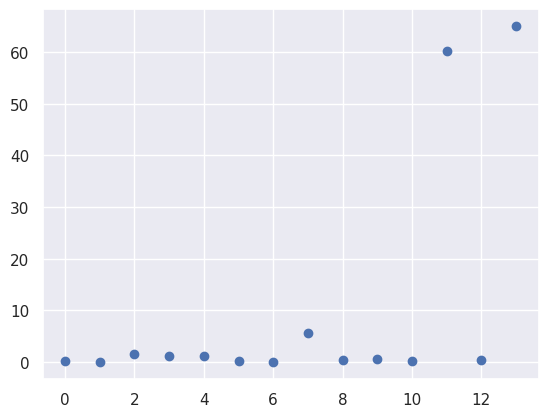

In [23]:
plt.scatter(np.arange(0,len(residuals)),residuals)

In [16]:
percent_error = residuals/df["desired_val"]

In [18]:
df["percent_error"] = percent_error*100

/local/rpinise1/3754629/ipykernel_3169481/3553926432.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["percent_error"] = percent_error*100


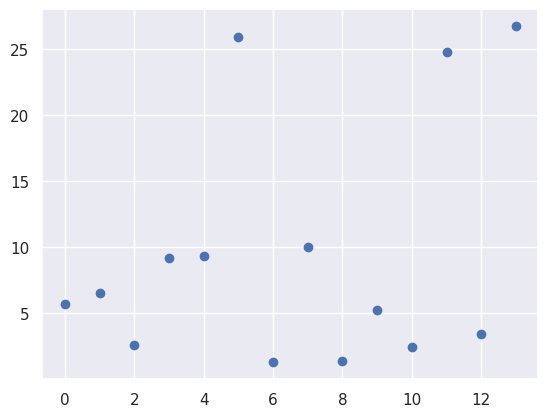

In [25]:
plt.scatter(np.arange(0,len(df["percent_error"])),df["percent_error"])

In [20]:
import numpy as np
from scipy import stats

def f_test_regression(y_true, y_pred, num_predictors=1):
    n = len(y_true)
    y_mean = np.mean(y_true)
    
    # Calculate Sum of Squares
    ss_reg = np.sum((y_pred - y_mean)**2)
    ss_res = np.sum((y_true - y_pred)**2)
    
    # Degrees of freedom
    df_reg = num_predictors
    df_res = n - num_predictors - 1
    
    # Mean Squares
    ms_reg = ss_reg / df_reg
    ms_res = ss_res / df_res
    
    # F-statistic
    f_stat = ms_reg / ms_res
    
    # P-value from F-distribution
    p_value = 1 - stats.f.cdf(f_stat, df_reg, df_res)
    
    return f_stat, p_value

# Usage
f_val, p_val = f_test_regression(df["desired_val"], df["actual_val"], num_predictors=1)
print(f"F-statistic: {f_val:.4f}, P-value: {p_val:.4e}")

F-statistic: 77.9043, P-value: 1.3557e-06


In [26]:
df

,column,desired_val,actual_val,percent_error
1,volume_ml,4.662286,4.929,5.720676
2,volume_ml,0.517142,0.551,6.547129
3,volume_ml,57.272589,55.789,2.590399
4,volume_ml,13.027158,14.227,9.210309
5,volume_ml,11.737662,12.830,9.306263
6,volume_ml,1.089673,1.372,25.909385
7,volume_ml,1.089673,1.104,1.314841
8,volume_ml,57.272589,51.548,9.995338
9,volume_ml,29.671052,29.266,1.365141
10,volume_ml,12.503197,11.847,5.248232
